In [1]:
import yfinance as yf
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster import hierarchy
from pathlib import Path
from datetime import datetime
import warnings

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3,
})
DATA_DIR = Path.cwd().parent/"data"; DATA_DIR.mkdir(exist_ok=True)

PROJECT_ROOT = Path(".").resolve().parent   
sys.path.insert(0, str(PROJECT_ROOT))
warnings.filterwarnings("ignore")

from src.config import ETF_UNIVERSE, START, END

In [2]:
TICKERS = list(ETF_UNIVERSE.keys())

raw = yf.download(
    TICKERS,
    start=START, 
    end=END,
    auto_adjust=True,
)
 
prices_raw  = raw["Close"].copy()
volumes_raw = raw["Volume"].copy()
 
print(f"\nRaw shape : {prices_raw.shape}  (rows = trading days, cols = ETFs)")
print(f"Dates     : {prices_raw.index[0].date()} → {prices_raw.index[-1].date()}")

[*********************100%***********************]  31 of 31 completed



Raw shape : (4108, 31)  (rows = trading days, cols = ETFs)
Dates     : 2010-01-04 → 2026-05-04


In [3]:
prices  = prices_raw.ffill().dropna(how="all")
volumes = (volumes_raw
           .ffill(limit=3)       
           .fillna(0)           
           .dropna(how="all"))
 
TICKERS = prices.columns.tolist()  
GROUPS = {}
for ticker, (desc, cat) in ETF_UNIVERSE.items():
    if ticker in TICKERS:  
        if cat not in GROUPS:
            GROUPS[cat] = []
        GROUPS[cat].append(ticker)

print(f"Automatically grouped {len(TICKERS)} ETFs into {len(GROUPS)} categories.")
 
print(f"After cleaning : {prices.shape[0]} days × {prices.shape[1]} ETFs")

Automatically grouped 31 ETFs into 5 categories.
After cleaning : 4108 days × 31 ETFs


In [4]:
daily_ret   = prices.pct_change().dropna(how="all")

log_ret     = np.log(prices / prices.shift(1)).dropna(how="all")

monthly_px  = prices.resample("ME").last()
monthly_ret = monthly_px.pct_change().dropna(how="all")
 
print(f"\ndaily_ret  : {daily_ret.shape}")
print(f"monthly_ret: {monthly_ret.shape}")


daily_ret  : (4107, 31)
monthly_ret: (196, 31)


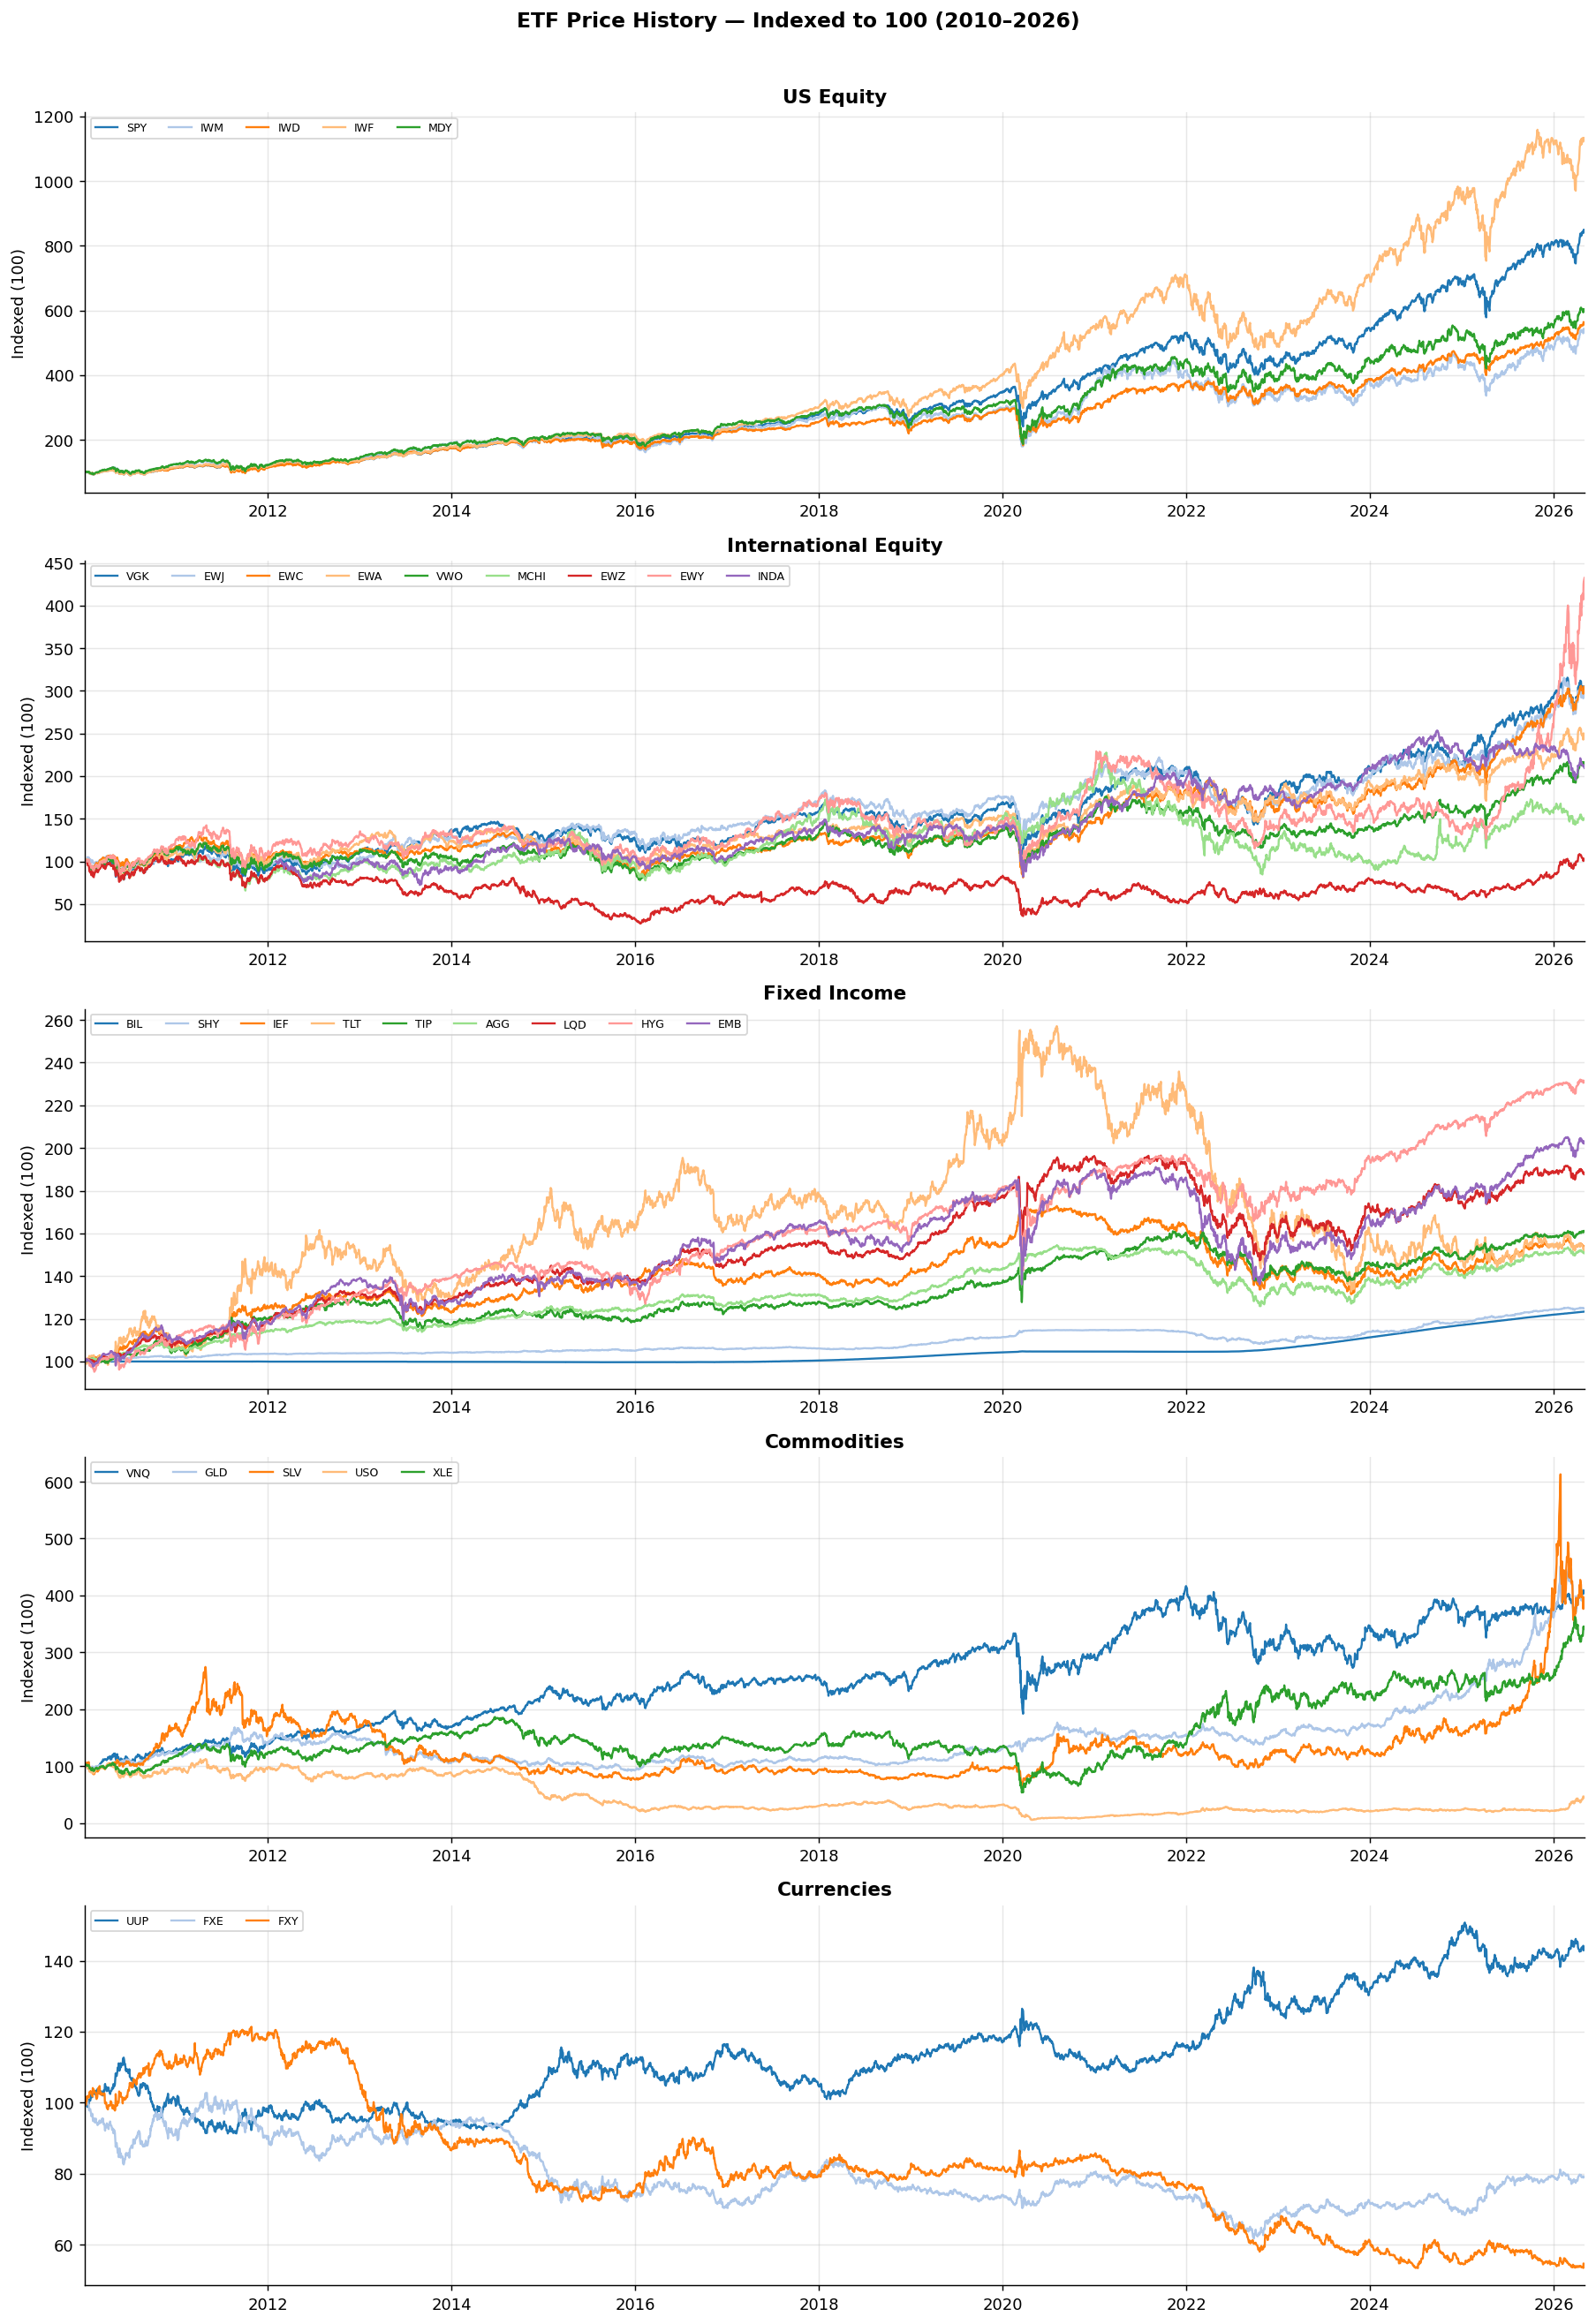

In [5]:
# -------------------- Plotting price history --------------------
fig, axes = plt.subplots(len(GROUPS), 1, figsize=(14, 4 * len(GROUPS)))

colors = plt.cm.tab20.colors
for ax, (grp, tks) in zip(axes, GROUPS.items()):
    first_valid_prices = prices[tks].bfill().iloc[0]
    norm = prices[tks].div(first_valid_prices) * 100


    for i, t in enumerate(tks):
        series = norm[t].dropna()
        ax.plot(norm.index, norm[t], label=t, lw=1.3, color=colors[i % 20])
    
    ax.set_xlim(norm.index.min(), norm.index.max())
    ax.set_title(grp, fontweight="bold")
    ax.legend(fontsize=7, ncol=len(tks), loc="upper left")
    ax.set_ylabel("Indexed (100)")
plt.suptitle(f"ETF Price History — Indexed to 100 ({START[:4]}–{END[:4]})",
             y=1.01, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(DATA_DIR / "00_price_history.png", bbox_inches="tight")
plt.show()

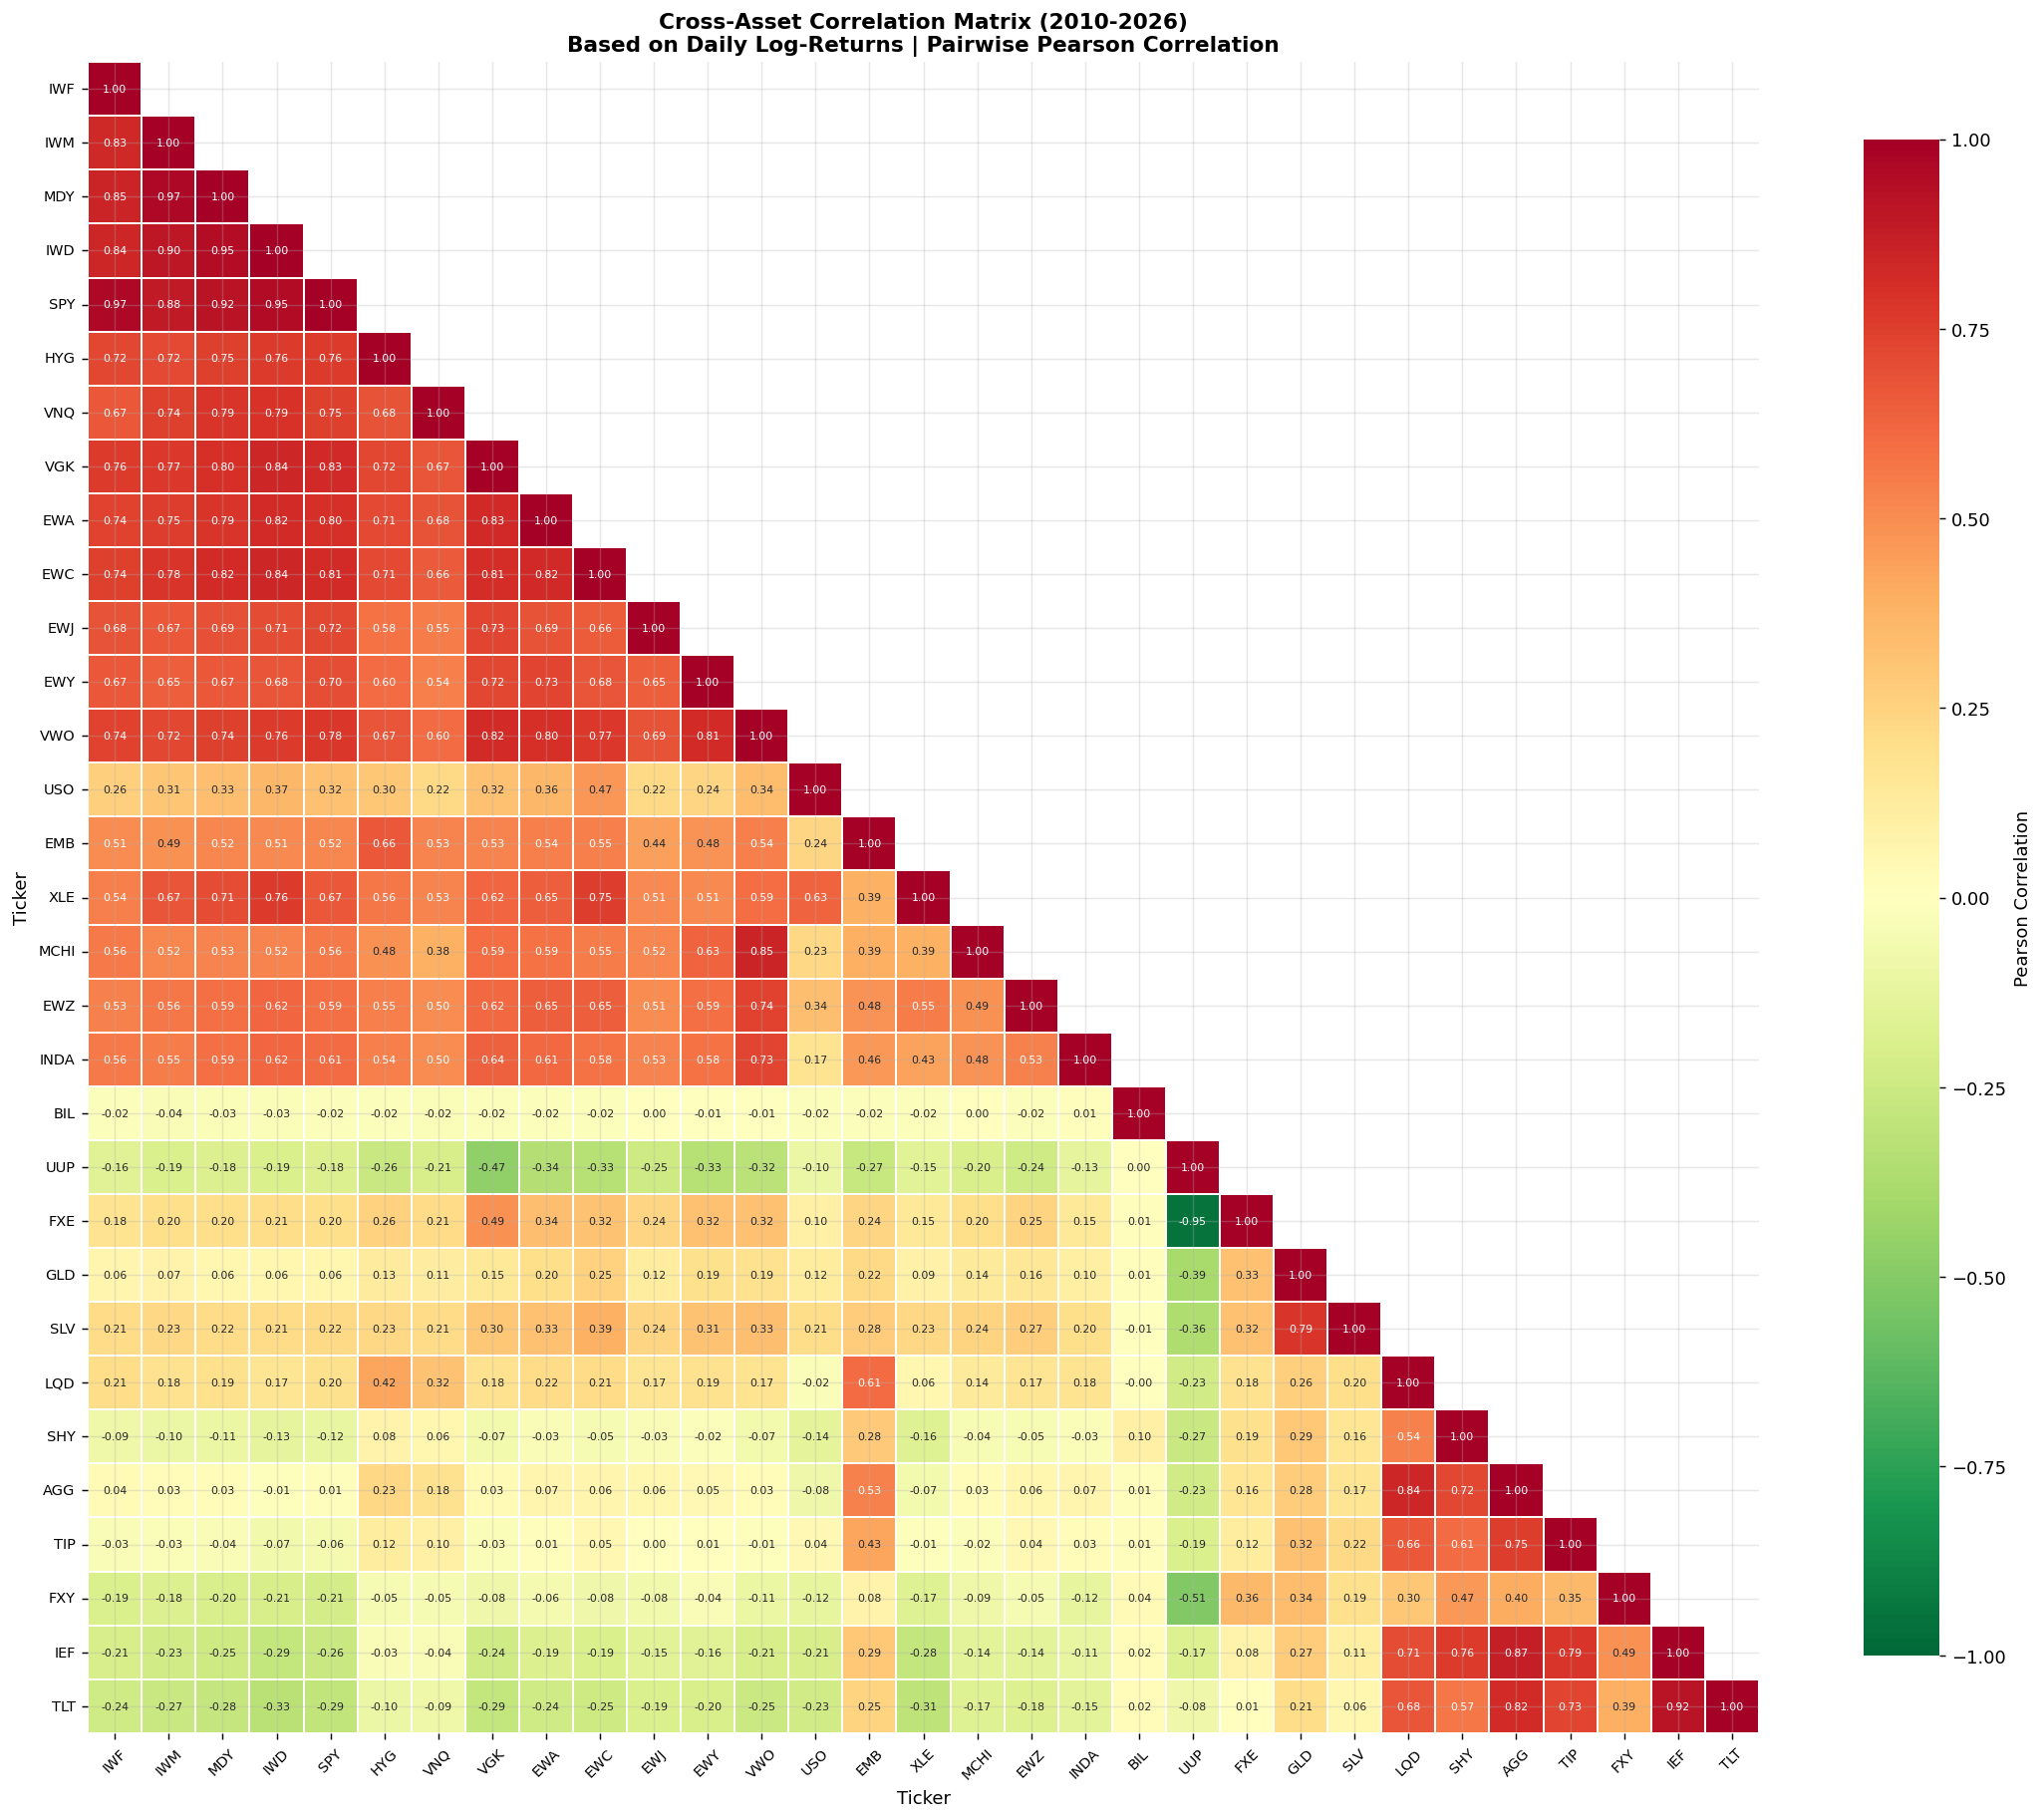

In [6]:
corr = daily_ret.corr()
dist   = 1 - corr
Z      = hierarchy.linkage(dist.values, method="ward")
leaves = hierarchy.leaves_list(Z)
order  = corr.columns[leaves].tolist()
corr_o = corr.loc[order, order]
 
fig, ax = plt.subplots(figsize=(17, 15))
mask = np.triu(np.ones_like(corr_o, dtype=bool), k=1)  # show lower triangle
 
sns.heatmap(
    corr_o, ax=ax, mask=mask,
    cmap="RdYlGn_r", vmin=-1, vmax=1, center=0,
    annot=True, fmt=".2f", annot_kws={"size": 6},
    linewidths=0.1, linecolor="white", square=True,
    cbar_kws={"shrink": 0.8, "label": "Pearson Correlation"},
)
ax.set_title(
    f"Cross-Asset Correlation Matrix ({START[:4]}-2026)\n"
    "Based on Daily Log-Returns | Pairwise Pearson Correlation",
    fontsize=12, fontweight="bold"
)
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0,  labelsize=8)
plt.tight_layout()
plt.savefig(DATA_DIR / "01_correlation_heatmap.png", bbox_inches="tight")
plt.show()

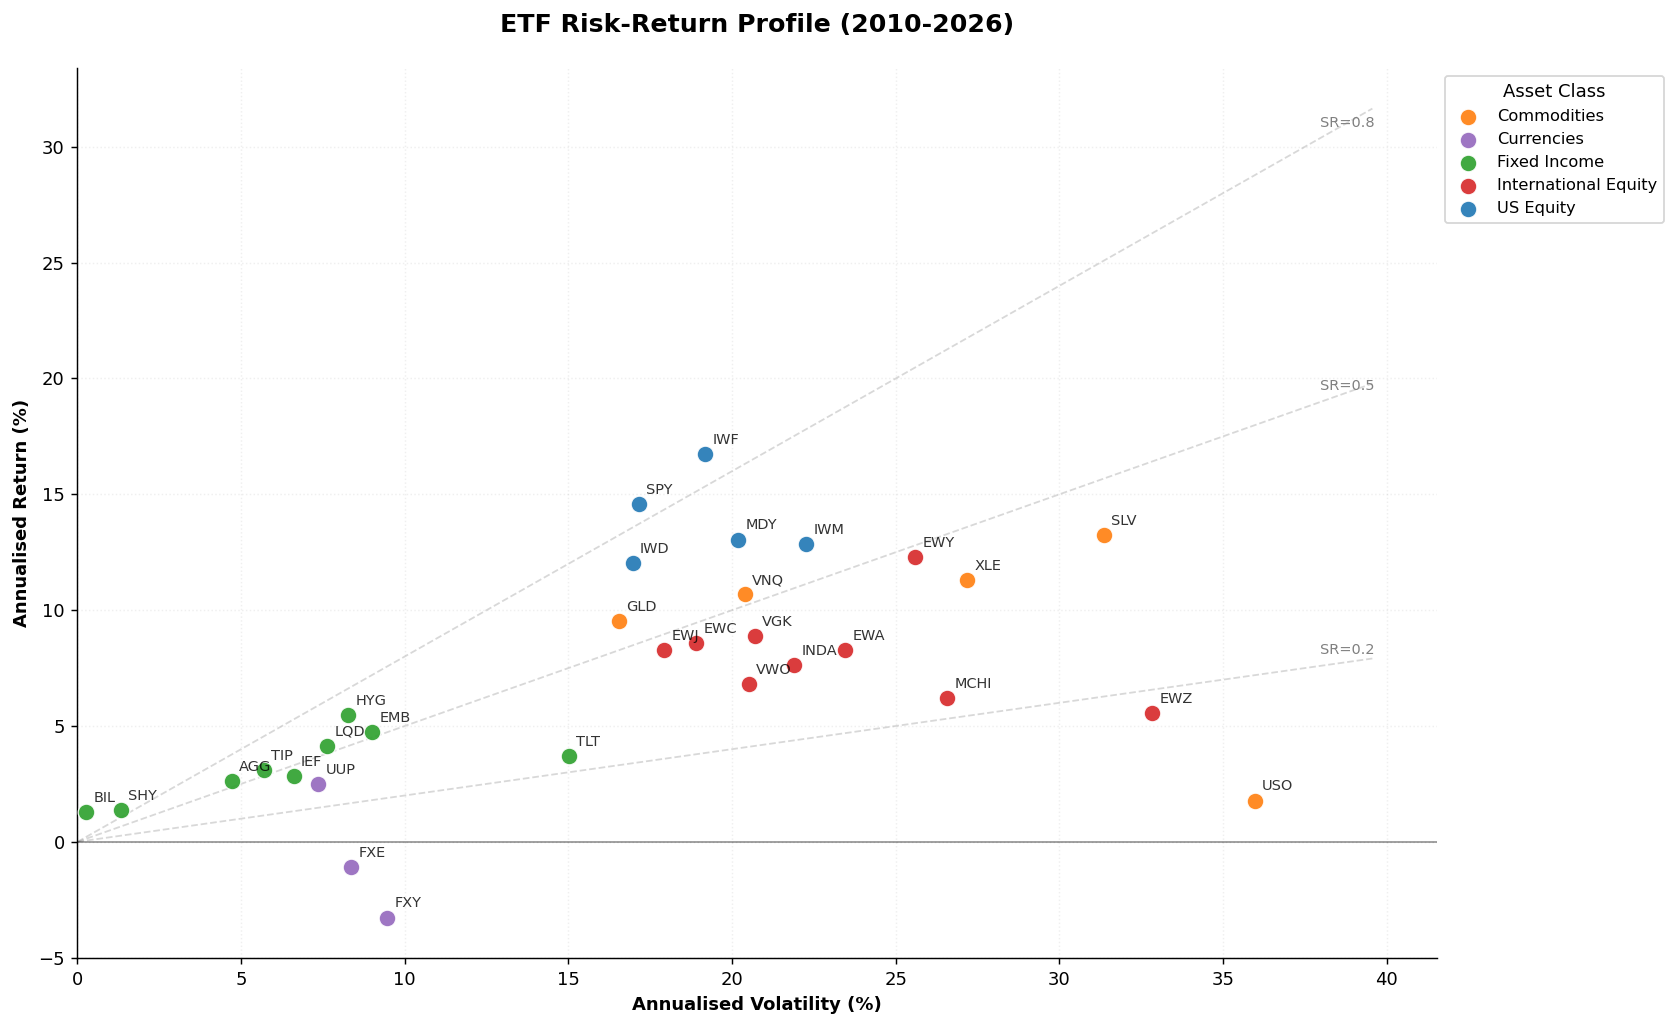

In [7]:
# -------------------- Risk-Return Scatter --------------------
ann_ret = daily_ret.mean() * 252 * 100
ann_vol = daily_ret.std()  * np.sqrt(252) * 100

palette = {
    "US Equity":    "#1f77b4", 
    "International Equity":  "#d62728",
    "Fixed Income": "#2ca02c",
    "Commodities":  "#ff7f0e",
    "Currencies":   "#9467bd"  
}

fig, ax = plt.subplots(figsize=(13, 8))

all_categories = sorted(list(set(cat for _, cat in ETF_UNIVERSE.values())))

for cls in all_categories:
    tks = [t for t, (desc, cat) in ETF_UNIVERSE.items() if cat == cls and t in daily_ret.columns]
    
    if not tks:
        continue
    
    color = palette.get(cls, "#7f7f7f") 
    
    ax.scatter(
        ann_vol[tks], ann_ret[tks], 
        c=color, s=85, label=cls, 
        zorder=3, edgecolors="white", lw=0.7, alpha=0.9
    )

    for t in tks:
        ax.annotate(
            t, (ann_vol[t], ann_ret[t]), 
            fontsize=8, ha="left", va="bottom",
            xytext=(4, 4), textcoords="offset points", 
            alpha=0.8, fontweight='medium'
        )

x_line = np.linspace(0, ann_vol.max() * 1.1, 100)
for sr in [0.2, 0.5, 0.8]:
    ax.plot(x_line, sr * x_line, "--", lw=1, color="grey", alpha=0.3, zorder=1)
    ax.text(x_line[-5], sr * x_line[-5] + 0.5, f"SR={sr}", fontsize=8, color="grey")

ax.axhline(0, color="black", lw=1, alpha=0.4, zorder=2)
ax.axvline(0, color="black", lw=1, alpha=0.4, zorder=2)
ax.set_xlabel("Annualised Volatility (%)", fontweight="bold")
ax.set_ylabel("Annualised Return (%)", fontweight="bold")
ax.set_title(f"ETF Risk-Return Profile ({START[:4]}-{END[:4]})", 
             fontsize=14, fontweight="bold", pad=20)
ax.legend(title="Asset Class", fontsize=9, loc="upper left", bbox_to_anchor=(1, 1), frameon=True)
ax.grid(True, alpha=0.2, linestyle=':')
ax.set_xlim(left=0)
plt.tight_layout()
plt.savefig(DATA_DIR / "02_risk_return_scatter.png", bbox_inches="tight", dpi=150)
plt.show()

In [8]:
# -------------------- Summary Table -------------------- 
sharpe = ann_ret / ann_vol
summary = pd.DataFrame({
    "Ticker":       ann_ret.index,
    "Asset Class":  [ETF_UNIVERSE[t][1] if t in ETF_UNIVERSE else "Other" for t in ann_ret.index],
    "Description":  [ETF_UNIVERSE[t][0] if t in ETF_UNIVERSE else "" for t in ann_ret.index],
    "Ann Return (%)": ann_ret.values,
    "Ann Vol (%)":    ann_vol.values,
    "Sharpe":         sharpe.values
})

summary = (summary
           .round(2)
           .sort_values("Sharpe", ascending=False)
           .reset_index(drop=True))

print(f"\n---------------------------- ETF Summary Statistics ({START[:4]}-2026) ----------------------------")
print(summary.to_string(index=False))


---------------------------- ETF Summary Statistics (2010-2026) ----------------------------
Ticker          Asset Class                 Description  Ann Return (%)  Ann Vol (%)  Sharpe
   BIL         Fixed Income                T-Bills 1-3M            1.29         0.27    4.83
   SHY         Fixed Income            Short Treasuries            1.37         1.34    1.02
   IWF            US Equity         US Large-Cap Growth           16.73        19.17    0.87
   SPY            US Equity      US Large Cap (S&P 500)           14.58        17.15    0.85
   IWD            US Equity          US Large-Cap Value           12.02        16.96    0.71
   HYG         Fixed Income             High-Yield Bond            5.47         8.27    0.66
   MDY            US Equity                  US Mid Cap           13.05        20.18    0.65
   GLD          Commodities                        Gold            9.53        16.53    0.58
   IWM            US Equity US Small Cap (Russell 2000)           12.